In [ ]:
import pandas as pd
df=pd.read_csv('air_quality.csv')
df.head(100)

,datetime,pm25,pm10,no2,co,so2,o3,temp,rh,wind,rain
0,01-01-2015 00:00,150.849670,257.310990,32.664554,1.204211,4.816183,1.364593,17.926895,42.058440,0.1,1.085120
1,01-01-2015 01:00,132.370120,254.495467,31.878915,0.860830,1.937702,1.000000,16.655569,37.960572,0.1,0.000000
2,01-01-2015 02:00,157.994518,256.419390,28.320158,0.074682,4.197653,2.516940,17.283748,37.412200,0.1,0.000000
3,01-01-2015 03:00,173.358215,269.406690,33.000651,2.563948,7.383085,1.000000,34.383131,17.713272,0.1,0.393723
4,01-01-2015 04:00,201.753827,335.956343,30.997890,1.326620,2.140768,1.000000,18.198381,39.903303,0.1,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
95,04-01-2015 23:00,159.194576,297.206252,17.553342,0.050000,5.363058,8.737344,16.878067,39.490309,0.1,0.895417
96,05-01-2015 00:00,176.071946,266.802784,23.789868,0.050000,4.840404,8.206477,10.000000,50.196200,0.1,0.000000
97,05-01-2015 01:00,138.281299,253.268419,39.764768,3.641615,5.029260,1.000000,32.832504,16.271832,0.1,1.520830
98,05-01-2015 02:00,162.518379,259.831562,28.866641,2.090719,4.998603,1.000000,19.224966,41.314436,0.1,0.053772


##DATA EXPLORATION AND CLEANING

In [ ]:
df.isnull().sum()

,0
datetime,0
pm25,0
pm10,0
no2,0
co,0
so2,0
o3,0
temp,0
rh,0
wind,0


FOR BETTER ANALYSIS WE WILL MAKE SEPERATE COLUMNS FOR THE YEAR, MONTH AND HOUR. FURTHER WE SHALL USE PANDAS WHICH - converts the data type from text to datetime IN OUR COLUMN 'DATETIME'

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'], format='%d-%m-%Y %H:%M')
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df.head()

,datetime,pm25,pm10,no2,co,so2,o3,temp,rh,wind,rain,year,month,hour
0,2015-01-01 00:00:00,150.849670,257.310990,32.664554,1.204211,4.816183,1.364593,17.926895,42.058440,0.1,1.085120,2015,1,0
1,2015-01-01 01:00:00,132.370120,254.495467,31.878915,0.860830,1.937702,1.000000,16.655569,37.960572,0.1,0.000000,2015,1,1
2,2015-01-01 02:00:00,157.994518,256.419390,28.320158,0.074682,4.197653,2.516940,17.283748,37.412200,0.1,0.000000,2015,1,2
3,2015-01-01 03:00:00,173.358215,269.406690,33.000651,2.563948,7.383085,1.000000,34.383131,17.713272,0.1,0.393723,2015,1,3
4,2015-01-01 04:00:00,201.753827,335.956343,30.997890,1.326620,2.140768,1.000000,18.198381,39.903303,0.1,0.000000,2015,1,4


##DATA VISUALIZATION

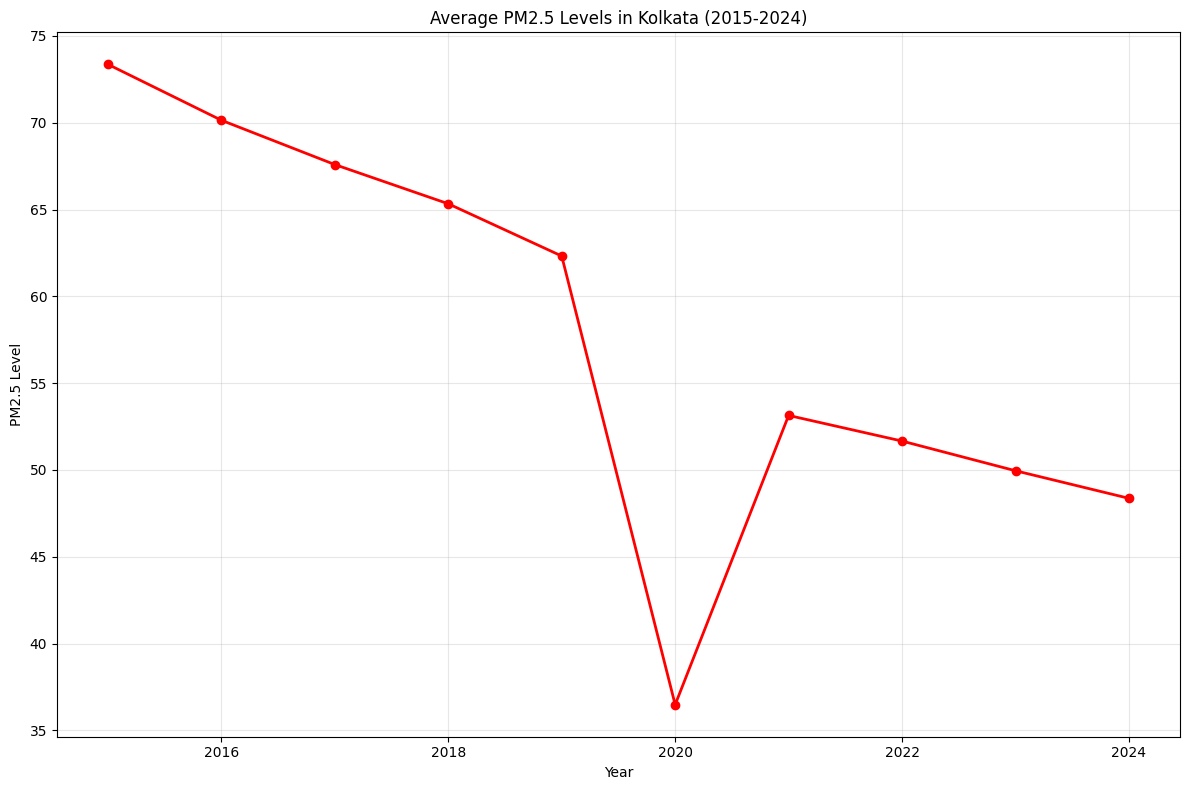

In [ ]:
import matplotlib.pyplot as plt

pm25_yearly = df.groupby('year')['pm25'].mean()

plt.figure(figsize=(12,8))
plt.plot(pm25_yearly.index, pm25_yearly.values, color='red', linewidth=2, marker='o')
plt.title('Average PM2.5 Levels in Kolkata (2015-2024)')
plt.xlabel('Year')
plt.ylabel('PM2.5 Level')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This diagram represents the yearly changes in the pm2.5 levels in kolkata from 2015 to 2024

PM2.5 levels were at their lowest in 2020 during covid, strongly
suggesting that vehicular traffic and industrial activity,both of which were brought to a near halt during the covid pandemic,
are the primary drivers of air pollution in Kolkata.


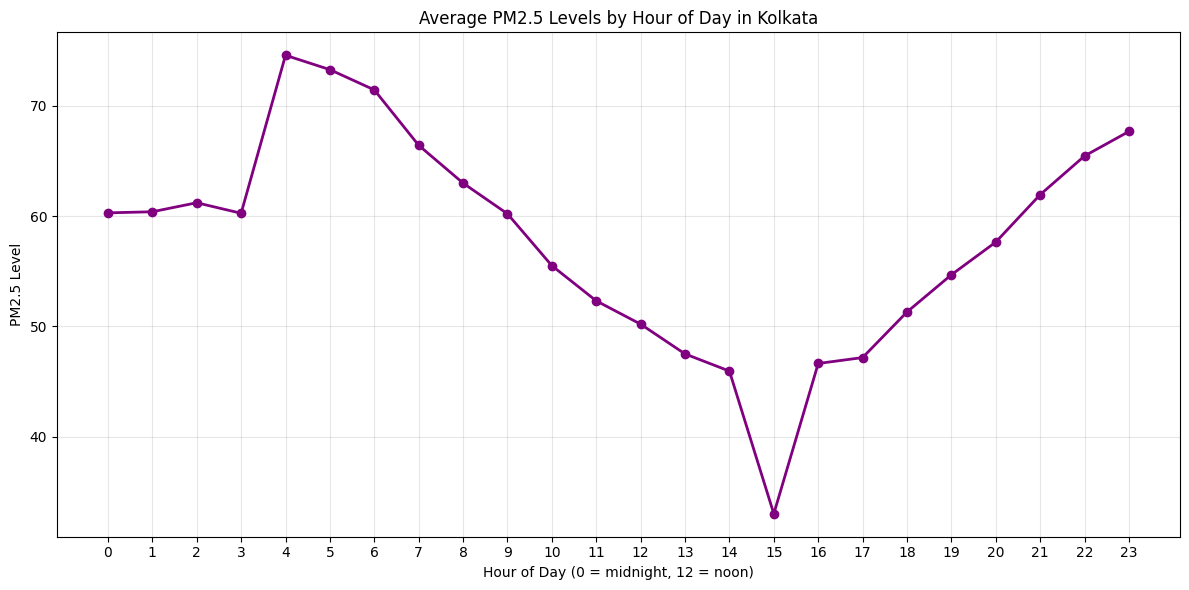

In [ ]:
pm25_hourly = df.groupby('hour')['pm25'].mean()

plt.figure(figsize=(12,6))
plt.plot(pm25_hourly.index, pm25_hourly.values, color='purple', linewidth=2, marker='o')
plt.title('Average PM2.5 Levels by Hour of Day in Kolkata')
plt.xlabel('Hour of Day (0 = midnight, 12 = noon)')
plt.ylabel('PM2.5 Level')
plt.xticks(range(0,24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This diagram shows hourly changes in pm2.5 levels throughtout the day

One of the major findings from this visualization is that pm2.5 levels are the highest at 4am.

Reasons why PM2.5 IS THE HIGHEST AT 4AM


*  At 4AM or Early morning is when a lot of garbage burning and waste disposal happens in the city — a major source of this pollutant

*   In the early morning cold air gets trapped near the ground with warmer air above it — this acts like a lid, trapping all pollutants close to the surface where we breathe


*  Heavy trucks and goods vehicles are banned from entering Kolkata during daytime hours. So they all enter the city between 2am–5am — diesel engines running all at once, causing a spike in pollution

*  During early morning hours wind speed is at its lowest. Pollutants just sit in the air and accumulate instead of being dispersed — by afternoon wind picks up and clears the air





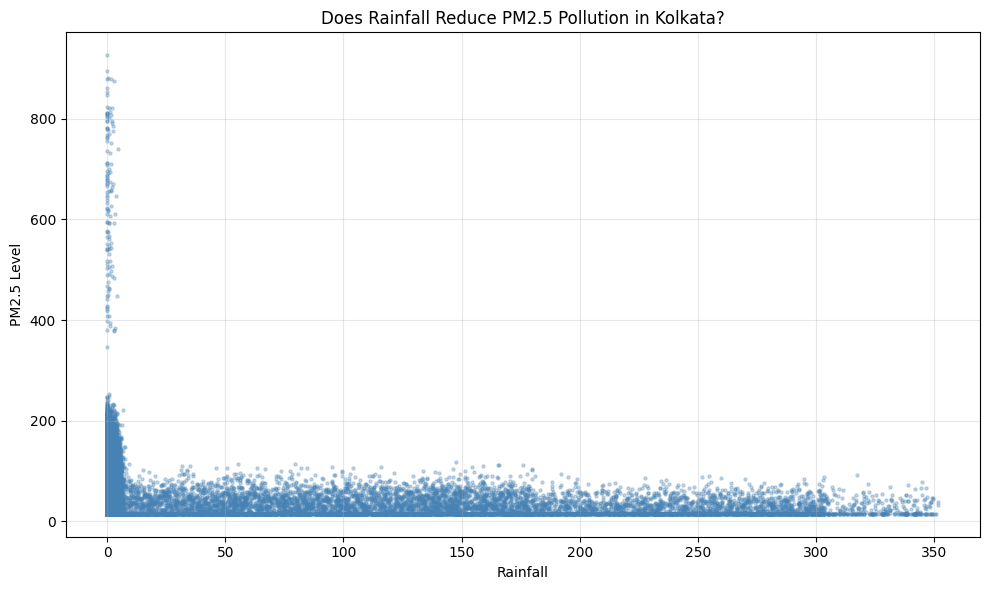

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df['rain'], df['pm25'], alpha=0.3, color='steelblue', s=5)
plt.title('Does Rainfall Reduce PM2.5 Pollution in Kolkata?')
plt.xlabel('Rainfall')
plt.ylabel('PM2.5 Level')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This diagram shows the relation between the rainfall and pm2.5 levels in kolkata


Most hours have low rainfall and low pollution — Which are the normal days in Kolkata.
But when there is NO rain, pollution can spike very high — those tall dots on the left are Kolkata's worst pollution days, all happening during dry weather.
When it rains, pollution stays low and controlled.
Thus, Rain is essentially acting as a natural air purifier for Kolkata

##SOLUTION
TO REDUCE SUCH A POLLUTANT THAT IS EVIDENTLY LOW DURING RAINFALL,
WATER SPRINKLERS/WATER SPRINKING TRUCKS THAT WOULD SIMULATE THE EFFECT OF RAIN
AND SIGNIFICANTLY REDUCE PM2.5 LEVELS CAN BE INSTALLED.

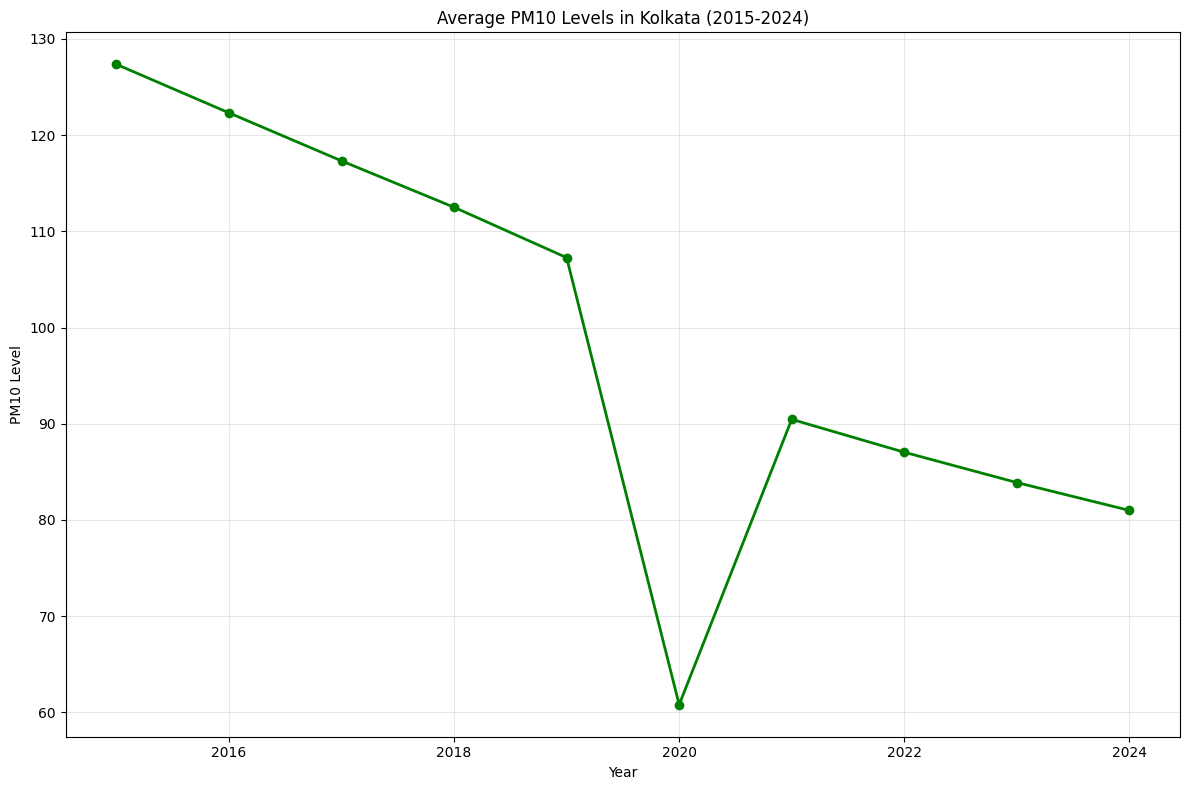

In [ ]:
import matplotlib.pyplot as plt

pm10_yearly = df.groupby('year')['pm10'].mean()

plt.figure(figsize=(12,8))
plt.plot(pm10_yearly.index, pm10_yearly.values, color='green', linewidth=2, marker='o')
plt.title('Average PM10 Levels in Kolkata (2015-2024)')
plt.xlabel('Year')
plt.ylabel('PM10 Level')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This diagram shows yealy changes in the pm10 levels in kolkata from 2015 to 2024.



In [ ]:
print(df['pm25'].corr(df['pm10']))

0.892664921248758


The levels of pm2.5 and pm10 are strongly positively correlated that shows that both the pollutants share the same sources in kolkata.
The line graph shows how 2020 had the lowest levels for both the pollutants confirming that vehicular emission and industrial activity are the major sources of these pollutants,that were evidently at a halt during the covid 19 pandemic

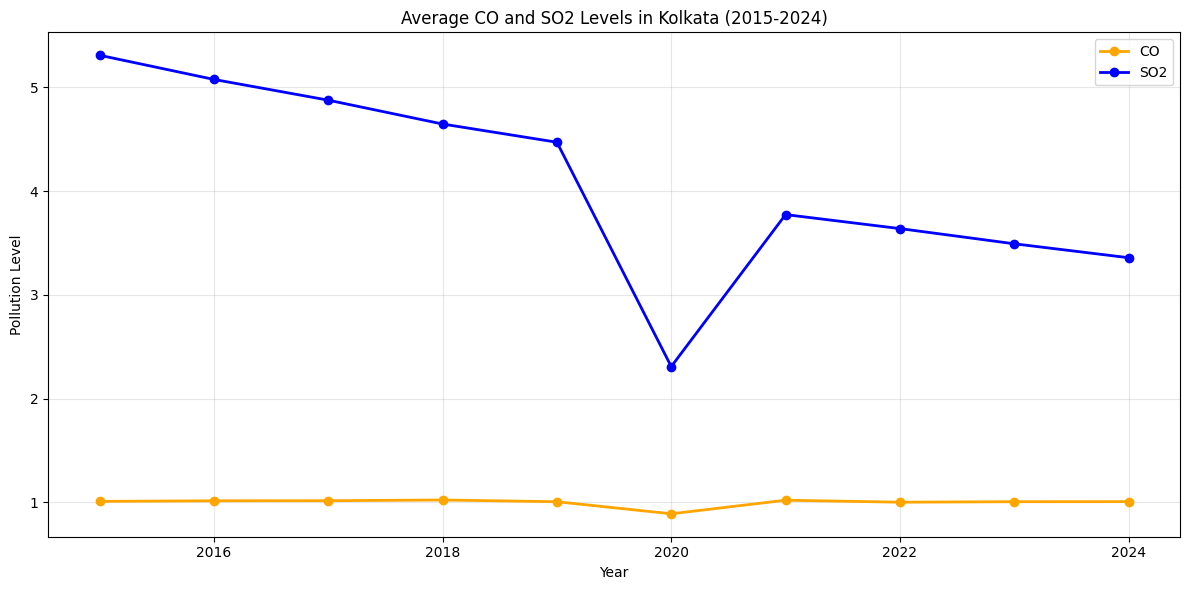

In [ ]:
co_yearly = df.groupby('year')['co'].mean()
so2_yearly = df.groupby('year')['so2'].mean()

plt.figure(figsize=(12,6))
plt.plot(co_yearly.index, co_yearly.values, color='orange', linewidth=2, marker='o', label='CO')
plt.plot(so2_yearly.index, so2_yearly.values, color='blue', linewidth=2, marker='o', label='SO2')
plt.title('Average CO and SO2 Levels in Kolkata (2015-2024)')
plt.xlabel('Year')
plt.ylabel('Pollution Level')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This diagram shows yearly trends of so2 and co levels in kolkata from 2015 to 2024


While most people assume that vehicular emission in kolkata, that are primary sources of co levels are the major contributors of  pollution ,the visualization tells us a different story. We can infact hold the so2 sources such as industrial and power plant activities majorly accountable for air pollution increase during the years 2015-2024 in kolkata

##How temperature affects pollution

The first diagram below shows how temperature and o3 levels are related in kolkata during 2015 to 2024.

The second diagram shows how o3 levels changes throughout the months in a year in kolkata.

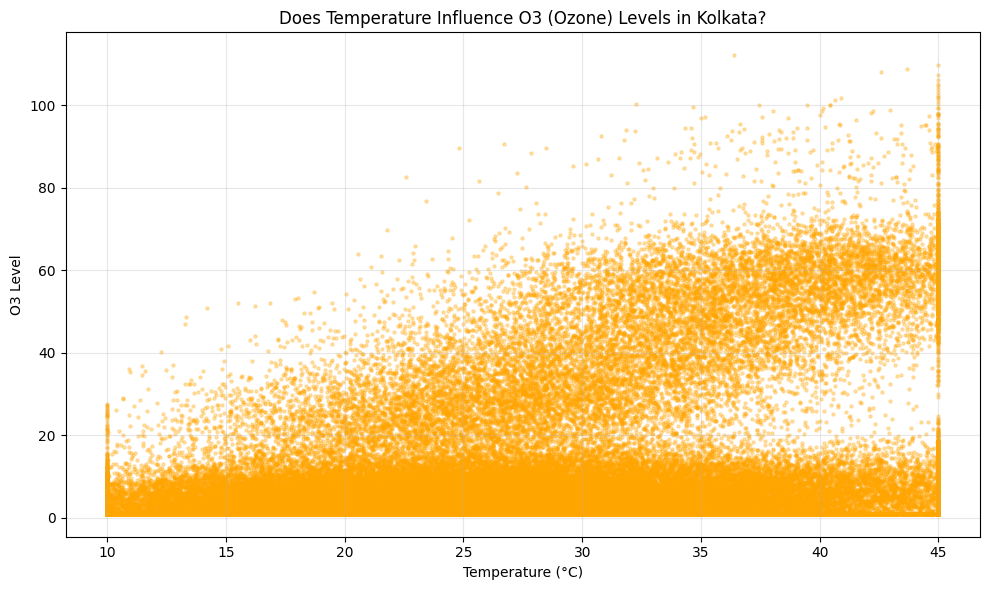

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df['temp'], df['o3'], alpha=0.3, color='orange', s=5)
plt.title('Does Temperature Influence O3 (Ozone) Levels in Kolkata?')
plt.xlabel('Temperature (°C)')
plt.ylabel('O3 Level')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

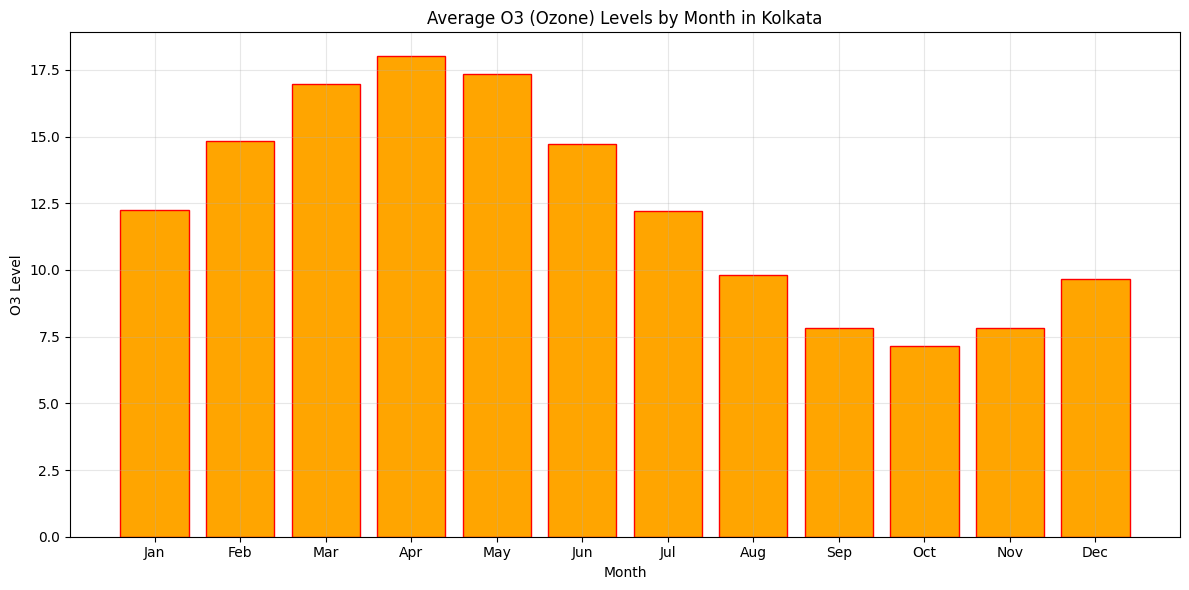

In [ ]:
o3_monthly = df.groupby('month')['o3'].mean()

plt.figure(figsize=(12,6))
plt.bar(range(1,13), o3_monthly.values, color='orange', edgecolor='red')
plt.title('Average O3 (Ozone) Levels by Month in Kolkata')
plt.xlabel('Month')
plt.ylabel('O3 Level')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

These two representations prove that when the temperature is high o3 levels are also high. Thus temperature drives ozone levels in kolkata.
O3 (ozone) levels follow a clear seasonal pattern too,in Kolkata,
with significantly higher levels during summer months
(April-June) and lower levels during winter (December-January).
This confirms that higher temperatures accelerate the chemical
reactions that produce ground level ozone, making summer
the most ozone-polluted season in Kolkata.

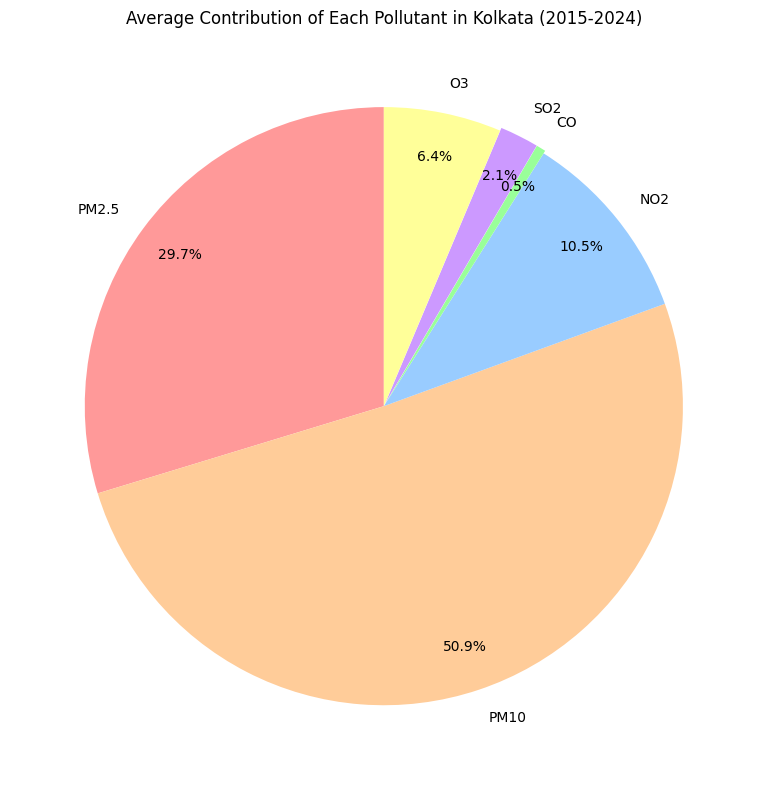

In [ ]:
pollutants = ['pm25', 'pm10', 'no2', 'co', 'so2', 'o3']
averages = [df[p].mean() for p in pollutants]

plt.figure(figsize=(12,8))
plt.pie(averages,
        labels=['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3'],
        autopct='%1.1f%%',
        colors=['#ff9999','#ffcc99','#99ccff','#99ff99','#cc99ff','#ffff99'],
        startangle=90,
        explode=(0, 0, 0, 0.01, 0.01, 0),
        pctdistance=0.85,
        labeldistance=1.1)
plt.title('Average Contribution of Each Pollutant in Kolkata (2015-2024)')
plt.tight_layout()
plt.show()

The above piechart shows the contribution of each pollutant in kolkata over the years (2015-2024)

Findings

This data analysis explores the air quality of Kolkata
between 2015 and 2024 using hourly pollution readings
across multiple pollutants including PM2.5, PM10, SO2,
CO, NO2 and O3.

The analysis reveals several key patterns.

Pollution levels were at their lowest in 2020 during the Covid
lockdown, strongly suggesting that industrial activity
and vehicular traffic are the primary drivers of air
pollution in Kolkata.

Contrary to popular belief, SO2
from industrial sources contributes more significantly
to Kolkata's pollution than CO from vehicular emissions.

The study also finds that pollution peaks at 4am daily
due to early morning truck movement, temperature
inversion and absence of wind.

Rainfall acts as a
natural air purifier, with the highest pollution spikes
occurring during dry periods.

O3 levels follow a clear
seasonal pattern, peaking in summer and dropping in
winter, confirming the direct influence of temperature
on ozone formation.

Overall this analysis highlights that tackling industrial
emissions and regulating early morning heavy vehicle
movement could be the most effective steps toward
improving air quality in Kolkata.